# LECTURE 13
**Topic:** Examples of the DFT and its Inverse; DFT of a Real-Valued Signal  
**Textbook References:** Sections 3.2, 3.3

---

## Key Points

- An N-point vector $s$ is a complex sinusoid of frequency $\omega=2k\pi/N$ iff $S[k]\neq 0$ and $S[m]=0$ for $m\neq k$.
- **Linearity (DFT 1):** $s=\alpha x+\beta y \;\leftrightarrow\; S=\alpha X+\beta Y$
- **Circular conjugate symmetry (DFT 2):** If $s$ is real, $S[N-k]=S^*[k]$ for $k=1:N-1$, and $S[0],\,S[N/2]$ are real.
- Real signal expressed as sum of sinusoids:
$$s[n]=\frac{1}{N}S[0]+\frac{2}{N}\sum_{0<k<N/2}|S[k]|\cos\!\left(\frac{2\pi kn}{N}+\angle S[k]\right)+\frac{1}{N}S[N/2](-1)^n$$


---
## Theory and Examples

### 1. Single Nonzero DFT Entry → Sinusoid

For $N=8$:

- $S=[0,0,0,0,1,0,0,0]^T$ (only $S[4]\neq 0$):
  $s = v^{(4)}/8$, frequency $\omega=4(2\pi/8)=\pi$ → alternating: $s[n]=(−1)^n/8$

- $S=[0,0,0,1,0,0,0,0]^T$ (only $S[3]\neq 0$):
  $s = v^{(3)}/8$, frequency $\omega=3\pi/4$

- $S=[0,0,0,1,0,1,0,0]^T$ ($S[3]=S[5]=1$):
  $s=(v^{(3)}+v^{(5)})/8$. Since $\omega=5\pi/4$ same as $-3\pi/4$ for complex sinusoids:
  $s[n]=\frac{1}{4}\cos(3\pi n/4)$


S[4]=1: s = [ 0.125 -0.125  0.125 -0.125  0.125 -0.125  0.125 -0.125]
 Expected: (-1)^n / 8 = [0.125, -0.125, 0.125, -0.125, 0.125, -0.125, 0.125, -0.125]

S[3]=1: s = [ 0.125 +0.j     -0.0884+0.0884j  0.    -0.125j   0.0884+0.0884j
 -0.125 +0.j      0.0884-0.0884j  0.    +0.125j  -0.0884-0.0884j]
 Expected (1/8)*exp(j*3pi/4*n): [np.complex128(0.125+0j), np.complex128(-0.08838834764831843+0.08838834764831845j), np.complex128(-2.296212748401287e-17-0.125j), np.complex128(0.08838834764831846+0.08838834764831842j), np.complex128(-0.125+4.592425496802574e-17j), np.complex128(0.08838834764831832-0.08838834764831856j), np.complex128(6.888638245203862e-17+0.125j), np.complex128(-0.08838834764831842-0.08838834764831846j)]

S[3]=S[5]=1: s = [ 0.25   -0.1768  0.      0.1768 -0.25    0.1768  0.     -0.1768]
 Expected cos(3pi*n/4)/4: [ 0.25   -0.1768 -0.      0.1768 -0.25    0.1768  0.     -0.1768]
 Match? True


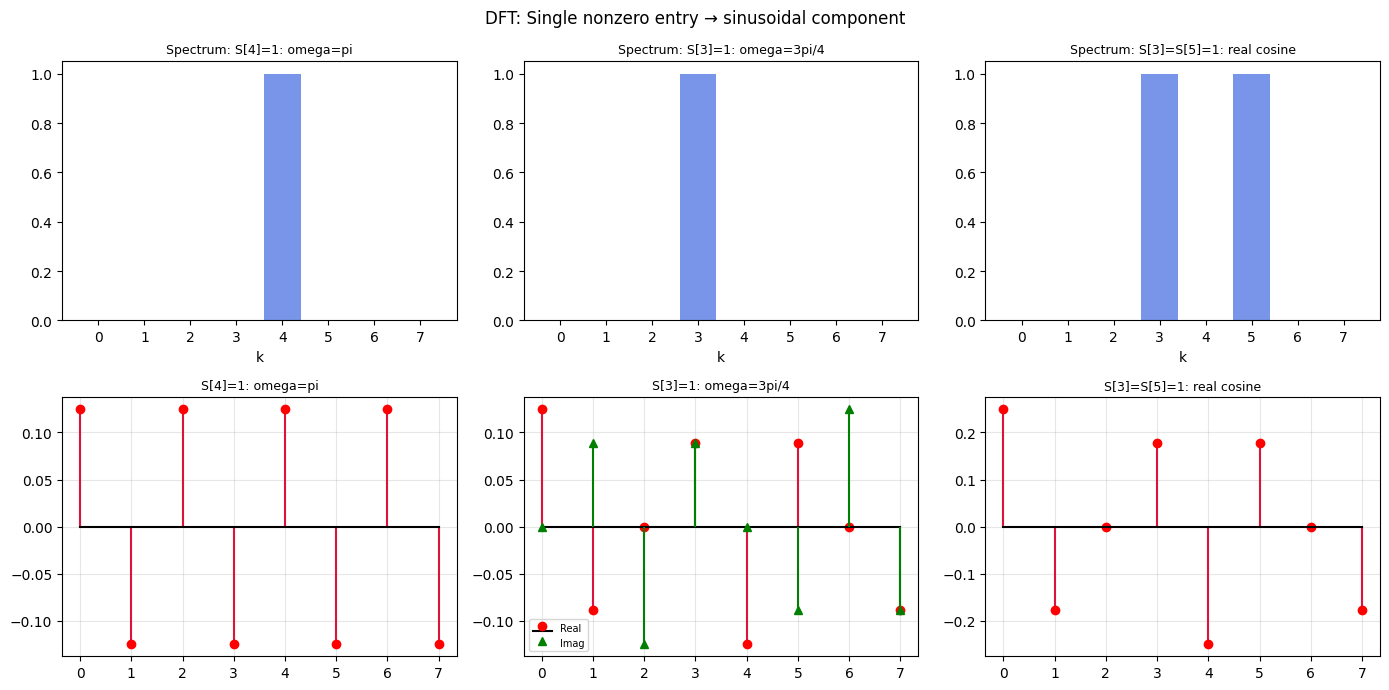

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 8

# Case 1: S[4]=1
S1 = np.zeros(N, dtype=complex); S1[4]=1
s1 = np.fft.ifft(S1)
print('S[4]=1: s =', s1.real.round(4))
print(' Expected: (-1)^n / 8 =', [(-1)**n/8 for n in range(N)])

# Case 2: S[3]=1
S2 = np.zeros(N, dtype=complex); S2[3]=1
s2 = np.fft.ifft(S2)
print('\nS[3]=1: s =', s2.round(4))
print(' Expected (1/8)*exp(j*3pi/4*n):', [(1/8)*np.exp(1j*3*np.pi/4*n) for n in range(N)])

# Case 3: S[3]=S[5]=1
S3 = np.zeros(N, dtype=complex); S3[3]=1; S3[5]=1
s3 = np.fft.ifft(S3)
s3_expected = np.cos(3*np.pi*np.arange(N)/4) / 4
print('\nS[3]=S[5]=1: s =', s3.real.round(4))
print(' Expected cos(3pi*n/4)/4:', s3_expected.round(4))
print(' Match?', np.allclose(s3.real, s3_expected))

# Visualize
fig, axes = plt.subplots(2,3,figsize=(14,7))
n = np.arange(N)
for col, (S_t, s_t, title) in enumerate([
    (S1,s1,'S[4]=1: omega=pi'),
    (S2,s2,'S[3]=1: omega=3pi/4'),
    (S3,s3,'S[3]=S[5]=1: real cosine')
]):
    axes[0][col].bar(n, np.abs(S_t), color='royalblue', alpha=0.7)
    axes[0][col].set_title(f'Spectrum: {title}', fontsize=9)
    axes[0][col].set_xlabel('k')
    axes[1][col].stem(n, s_t.real, linefmt='crimson', markerfmt='ro', basefmt='k', label='Real')
    if np.any(np.abs(s_t.imag)>1e-10):
        axes[1][col].stem(n, s_t.imag, linefmt='green', markerfmt='g^', basefmt=' ', label='Imag')
        axes[1][col].legend(fontsize=7)
    axes[1][col].set_title(title, fontsize=9); axes[1][col].grid(True,alpha=0.3)
plt.suptitle('DFT: Single nonzero entry → sinusoidal component', fontsize=12)
plt.tight_layout(); plt.show()

---
### 2. Linearity of the DFT (DFT 1)

Both analysis and synthesis are linear (matrix multiplication by $W$ or $V$):
$$s=\alpha x+\beta y \;\stackrel{\text{DFT}}{\longleftrightarrow}\; S=\alpha X+\beta Y$$

**Example:** Invert $S=[1,0,0,3,-2,3,0,0]^T$ ($N=8$):
- $S[0]=1$: contributes $s_0[n]=1/8$
- $S[3]=S[5]=3$: contributes $s_1[n]=(3/4)\cos(3\pi n/4)$
- $S[4]=-2$: contributes $s_2[n]=(-1/4)(-1)^n$

$$\Rightarrow s[n]=\tfrac{1}{8}+\tfrac{3}{4}\cos(3\pi n/4)-\tfrac{1}{4}(-1)^n$$

### 3. Why Must $S[k]=S[N-k]$ for a Real Signal?

If $S[3]=3$ but $S[5]=-1$ (not conjugate pair), then combining $v^{(3)}$ and $v^{(5)}$ gives
$s[n]=(3e^{j3\pi n/4}-e^{-j3\pi n/4})/8$, which is NOT purely real (imaginary parts do not cancel).


Invert S = [1,0,0,3,-2,3,0,0]:
  ifft result: [ 0.625  -0.1553 -0.125   0.9053 -0.875   0.9053 -0.125  -0.1553]
  formula:     [ 0.625  -0.1553 -0.125   0.9053 -0.875   0.9053 -0.125  -0.1553]
  Match? True

S[3]=3, S[5]=-1 (not conjugate pair):
  s imaginary part: [ 0.      0.3536 -0.5     0.3536  0.     -0.3536  0.5    -0.3536]  <- NOT zero, so not real!
  For real signal need S[5]=S[3]*=(3+0j)


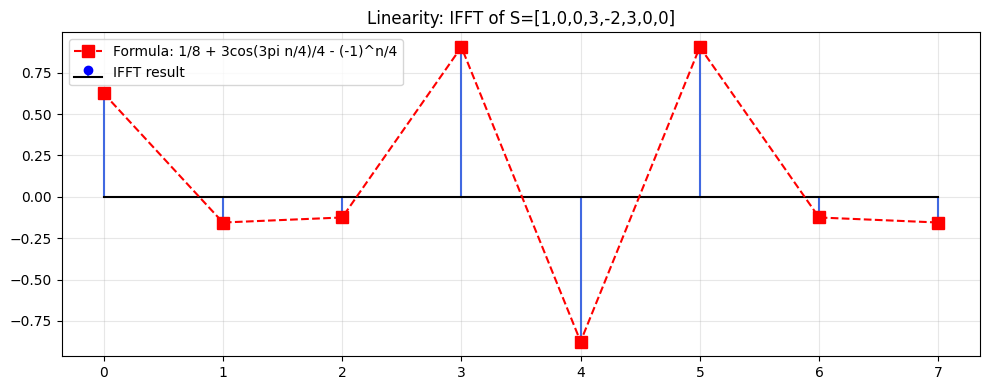

In [2]:
# Linearity: invert S = [1,0,0,3,-2,3,0,0]
S_ex = np.array([1,0,0,3,-2,3,0,0], dtype=complex)
n = np.arange(8)
s_direct = np.fft.ifft(S_ex)
s_formula = 1/8 - (-1)**n/4 + 3*np.cos(3*np.pi*n/4)/4

print('Invert S = [1,0,0,3,-2,3,0,0]:')
print('  ifft result:', s_direct.real.round(4))
print('  formula:    ', s_formula.round(4))
print('  Match?', np.allclose(s_direct.real, s_formula))

# Demonstrate what happens when S[3] != S[5]*
S_bad = np.array([1,0,0,3,0,-1,0,0], dtype=complex)
s_bad = np.fft.ifft(S_bad)
print(f'\nS[3]=3, S[5]=-1 (not conjugate pair):')
print(f'  s imaginary part: {s_bad.imag.round(4)}  <- NOT zero, so not real!')
print(f'  For real signal need S[5]=S[3]*={S_ex[3]}')

fig, ax = plt.subplots(figsize=(10,4))
ax.stem(n, s_direct.real, linefmt='royalblue', markerfmt='bo', basefmt='k', label='IFFT result')
ax.plot(n, s_formula, 'r--', marker='s', ms=8, label='Formula: 1/8 + 3cos(3pi n/4)/4 - (-1)^n/4')
ax.set_title('Linearity: IFFT of S=[1,0,0,3,-2,3,0,0]'); ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

---
### 4–8. DFT of a Real-Valued Signal: Circular Conjugate Symmetry (DFT 2)

If $s$ is real, the DFT satisfies:
$$S[N-k] = S^*[k], \quad k=1:N-1$$
$$S[0]=\text{real},\quad S[N/2]=\text{real (if } N \text{ even)}$$

**Proof:** $v^{(k)}$ and $v^{(N-k)}$ are complex conjugates.
$S[k]=\langle v^{(k)},s\rangle = a^Ts+jb^Ts$ and $S[N-k]=(a-jb)^Ts=a^Ts-jb^Ts = S^*[k]$ since $s$ real.

**Special values:**
- $S[0]=s[0]+s[1]+\cdots+s[N-1]$ (sum of all samples — real)
- $S[N/2]=s[0]-s[1]+s[2]-\cdots$ (alternating sum — real, $N$ even only)

**Result:** Odd $N$: 1 real + $(N-1)/2$ conjugate pairs. Even $N$: 2 real + $(N-2)/2$ conjugate pairs.


=== N=9 (odd) ===
  S[0] = 3.9381+0.0000j  (should be real: True)
  Conjugate symmetry check:
    S[8] = S*[1]? True
    S[7] = S*[2]? True
    S[6] = S*[3]? True
    S[5] = S*[4]? True
  All pairs conjugate symmetric: True

=== N=10 (even) ===
  S[0] = -5.9517+0.0000j  (should be real: True)
  S[N/2]=S[5] = 1.7827+-0.0000j  (should be real: True)
  Conjugate symmetry check:
    S[9] = S*[1]? True
    S[8] = S*[2]? True
    S[7] = S*[3]? True
    S[6] = S*[4]? True
  All pairs conjugate symmetric: True



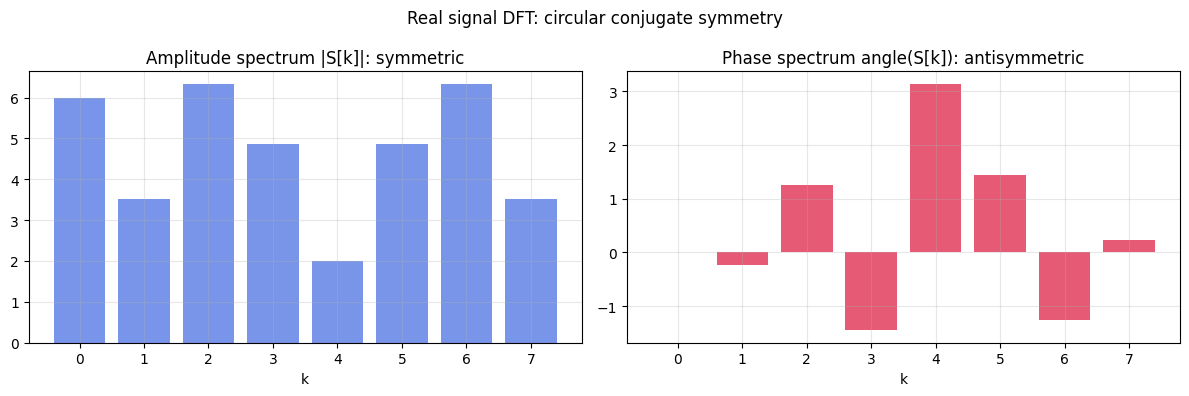

In [ ]:
# Verify circular conjugate symmetry
np.random.seed(42)
for N_test, label in [(9,'N=9 (odd)'), (10,'N=10 (even)')]:
    s_rand = np.random.randn(N_test)
    S_rand = np.fft.fft(s_rand)
    print(f'=== {label} ===')
    print(f'  S[0] = {S_rand[0].real:.4f}+{S_rand[0].imag:.4f}j  (should be real: {np.isclose(S_rand[0].imag,0)})')
    if N_test%2==0:
        print(f'  S[N/2]=S[{N_test//2}] = {S_rand[N_test//2].real:.4f}+{S_rand[N_test//2].imag:.4f}j  (should be real: {np.isclose(S_rand[N_test//2].imag,0)})')
    print('  Conjugate symmetry check:')
    for k in range(1, N_test//2+1):
        ok = np.isclose(S_rand[N_test-k], S_rand[k].conj())
        if k <= 4 or not ok:
            print(f'    S[{N_test-k}] = S*[{k}]? {ok}')
    print(f'  All pairs conjugate symmetric: {np.allclose(S_rand[1:], np.conj(S_rand[1:][::-1]))}')
    print()

# Visualize amplitude and phase spectrum
s_test = np.array([2,1,-1,3,0,-2,1,2], dtype=float)
S_test = np.fft.fft(s_test)
N_t = len(s_test)
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].bar(range(N_t), np.abs(S_test), color='royalblue', alpha=0.7)
axes[0].set_title('Amplitude spectrum |S[k]|: symmetric'); axes[0].set_xlabel('k'); axes[0].grid(True,alpha=0.3)
axes[1].bar(range(N_t), np.angle(S_test), color='crimson', alpha=0.7)
axes[1].set_title('Phase spectrum angle(S[k]): antisymmetric'); axes[1].set_xlabel('k'); axes[1].grid(True,alpha=0.3)
plt.suptitle('Real signal DFT: circular conjugate symmetry', fontsize=12)
plt.tight_layout(); plt.show()

---
### 9–10. Real Signal as Sum of Cosines

For a real $N$-point signal with spectrum $S$:
$$s[n] = \frac{S[0]}{N} + \frac{2}{N}\sum_{0<k<N/2}|S[k]|\cos\!\left(\frac{2\pi kn}{N}+\angle S[k]\right) + \frac{S[N/2]}{N}(-1)^n$$

**Example:** $S=[1,\,1+2j,\,-4j,\,3-j,\,-2,\,3+j,\,4j,\,1-2j]^T$ ($N=8$)

Polar form of each entry: $|S[k]|$ and $\angle S[k]$:

$$
\begin{array}{c|c|c|c}
\mathbf{k} & S[k] & |S[k]| & \angle S[k] \\ \hline
0 & 1 & 1 & 0 \\
1 & 1+2j & \sqrt{5} & 1.1071 \\
2 & -4j & 4 & -\frac{\pi}{2} \\
3 & 3 - j & \sqrt{10} & -0.3218 \\
4 & -2 & 2 & \pi \\
\end{array}
$$



$$s[n]=\tfrac{1}{8}+\tfrac{\sqrt{5}}{4}\cos(\tfrac{\pi n}{4}+1.1071)+\cos(\tfrac{\pi n}{2}-\tfrac{\pi}{2})+\tfrac{\sqrt{10}}{4}\cos(\tfrac{3\pi n}{4}-0.3218)-\tfrac{1}{4}(-1)^n$$


In [5]:
# Real signal synthesis from conjugate-symmetric DFT
S_ex2 = np.array([1, 1+2j, -4j, 3-1j, -2, 3+1j, 4j, 1-2j], dtype=complex)
N = 8; n = np.arange(N)

# Verify conjugate symmetry
print('Checking conjugate symmetry:')
for k in range(1,N):
    print(f'  S[{N-k}]={S_ex2[N-k]:.2f} vs S[{k}]*={S_ex2[k].conj():.2f}  OK={np.isclose(S_ex2[N-k],S_ex2[k].conj())}')

# IFFT
s_result = np.fft.ifft(S_ex2)
print(f'\nIFFT result (should be real): {s_result.real.round(4)}')
print(f'Imaginary part (should be ~0): {s_result.imag.round(10)}')

# Build from formula
s_formula2 = S_ex2[0].real/N
for k in range(1,N//2):
    A = abs(S_ex2[k]); phi = np.angle(S_ex2[k])
    s_formula2 += 2*A/N * np.cos(2*np.pi*k*n/N + phi)
s_formula2 += S_ex2[N//2].real/N * (-1)**n

print(f'\nFormula result: {s_formula2.round(4)}')
print(f'Match IFFT: {np.allclose(s_result.real, s_formula2)}')

# Polar form table
print('\nPolar form of S:')
print(f'{"k":>4}  {"S[k]":>15}  {"mag":>8}  {"phase":>8}')
for k in range(N):
    print(f'{k:>4}  {str(S_ex2[k].round(3)):>15}  {abs(S_ex2[k]):>8.4f}  {np.angle(S_ex2[k]):>8.4f}')

Checking conjugate symmetry:
  S[7]=1.00-2.00j vs S[1]*=1.00-2.00j  OK=True
  S[6]=0.00+4.00j vs S[2]*=-0.00+4.00j  OK=True
  S[5]=3.00+1.00j vs S[3]*=3.00+1.00j  OK=True
  S[4]=-2.00+0.00j vs S[4]*=-2.00-0.00j  OK=True
  S[3]=3.00-1.00j vs S[5]*=3.00-1.00j  OK=True
  S[2]=-0.00-4.00j vs S[6]*=0.00-4.00j  OK=True
  S[1]=1.00+2.00j vs S[7]*=1.00+2.00j  OK=True

IFFT result (should be real): [ 0.875   0.8447 -0.875  -0.4482 -1.125   1.9053  0.625  -0.8018]
Imaginary part (should be ~0): [0. 0. 0. 0. 0. 0. 0. 0.]

Formula result: [ 0.875   0.8447 -0.875  -0.4482 -1.125   1.9053  0.625  -0.8018]
Match IFFT: True

Polar form of S:
   k             S[k]       mag     phase
   0           (1+0j)    1.0000    0.0000
   1           (1+2j)    2.2361    1.1071
   2          (-0-4j)    4.0000   -1.5708
   3           (3-1j)    3.1623   -0.3218
   4          (-2+0j)    2.0000    3.1416
   5           (3+1j)    3.1623    0.3218
   6               4j    4.0000    1.5708
   7           (1-2j)    2.236

---
## Summary

| Property | Formula |
|---|---|
| Linearity (DFT 1) | $\alpha x+\beta y\leftrightarrow\alpha X+\beta Y$ |
| Conj symmetry (DFT 2) | $S[N-k]=S^*[k]$ for real $s$ |
| Amplitude spectrum | $|S[N-k]|=|S[k]|$ (symmetric) |
| Phase spectrum | $\angle S[N-k]=-\angle S[k]$ (antisymmetric) |

### Mistakes to Avoid
1. For a real IFFT result, you must have $S[N-k]=S^*[k]$. If they are not conjugate pairs, the IFFT will have nonzero imaginary parts.
2. $S[0]$ = **sum** of all samples (not mean — divide by $N$ to get mean).
3. The $(-1)^n$ term appears **only** when $N$ is even (at $k=N/2$).
